# Import Required Libraries

We begin by importing the necessary libraries for data generation, visualization, model training, and evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

# Generate a Nonlinear Dataset

The `make_circles()` function generates two concentric circles belonging to different classes.

This dataset is intentionally nonlinearly separable, making it a useful example for demonstrating the importance of kernel methods in Support Vector Machines.

In [2]:
X,y = make_circles(
    n_samples=200,
    factor=0.3,
    noise=0.05,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Visualize the Dataset

The scatter plot below shows the generated circular dataset.

Notice that a straight line cannot separate the two classes effectively.

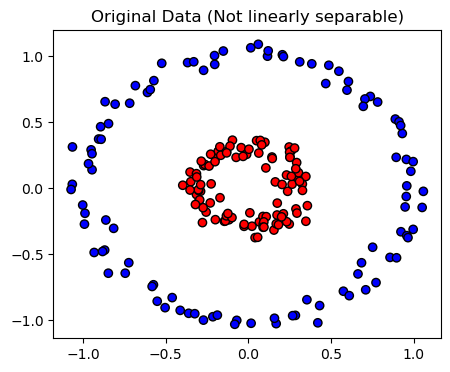

In [3]:
plt.figure(figsize=(5,4))
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.title("Original Data (Not linearly separable)")

plt.savefig(
    "original_circle_dataset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Kernel Comparison

Support Vector Machines can use different kernel functions to transform data into higher-dimensional feature spaces.

In this experiment, we compare:

**Linear Kernel**

Decision boundary:

w · x + b = 0

The linear kernel works well when data is linearly separable.

**Polynomial Kernel**

Kernel function:

K(x,y) = (x · y + c)^d

where:

- c is a constant
- d is the polynomial degree

**Radial Basis Function (RBF) Kernel**

Kernel function:

K(x,y) = exp(-γ ||x-y||²)

where:

- γ controls the influence of training samples
- Larger γ creates more complex boundaries

Each kernel is trained on the circular dataset.

Training accuracy is computed to compare their ability to model nonlinear structures.

In [4]:
kernels={
    "Linear": SVC(kernel="linear",C=1.0),
    "Poly": SVC(kernel="poly",degree=3,C=1.0),
    "RBF": SVC(kernel="rbf",gamma=0.01,C=1.0),
}

models = {}

for name, model in kernels.items():
    model.fit(X_train, y_train)
    models[name] = model

def evaluate_model(name, model):
    pred = model.predict(X_test)

    report = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, pred),
        "Confusion Matrix": confusion_matrix(y_test, pred)
    }

    return report

results = []

for name, model in models.items():
    results.append(evaluate_model(name, model))

for r in results:
    print("\n==============================")
    print("Model:", r["Model"])
    print("Accuracy:", round(r["Accuracy"], 4))
    print("F1 Score:", round(r["F1 Score"], 4))
    print("ROC AUC:", round(r["ROC AUC"], 4))
    print("Confusion Matrix:\n", r["Confusion Matrix"])


Model: Linear
Accuracy: 0.625
F1 Score: 0.7059
ROC AUC: 0.6591
Confusion Matrix:
 [[ 7 15]
 [ 0 18]]

Model: Poly
Accuracy: 0.575
F1 Score: 0.6792
ROC AUC: 0.6136
Confusion Matrix:
 [[ 5 17]
 [ 0 18]]

Model: RBF
Accuracy: 0.45
F1 Score: 0.6207
ROC AUC: 0.5
Confusion Matrix:
 [[ 0 22]
 [ 0 18]]


# RBF Decision Boundary

The RBF kernel creates a nonlinear decision boundary capable of separating the two circular classes.

To visualize this boundary:

1. Create a mesh grid covering the feature space.
2. Predict class labels for each grid point.
3. Plot classification regions using contour plots.
4. Highlight support vectors.

In [5]:
rbf_model=kernels["RBF"]

xx,yy=np.meshgrid(
    np.linspace(X[:,0].min()-0.2,X[:,0].max()+0.2,200),
    np.linspace(X[:,1].min()-0.2,X[:,1].max()+0.2,200)
)

grid=np.c_[xx.ravel(),yy.ravel()]

Z=rbf_model.predict(grid).reshape(xx.shape)

In [6]:
rbf_model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Decision Boundary Plot

Support vectors are shown as hollow circles.

These points are the critical training samples that determine the position of the separating boundary.

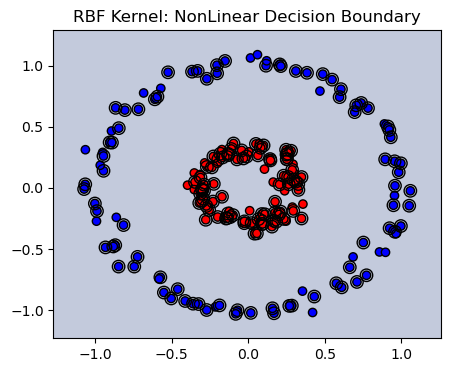

In [7]:
plt.figure(figsize=(5,4))

plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.scatter(
    rbf_model.support_vectors_[:,0],
    rbf_model.support_vectors_[:,1],
    s=80,
    facecolors="none",
    edgecolors="black",
)

plt.title("RBF Kernel: NonLinear Decision Boundary")

plt.savefig(
    "rbf_decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()